## Práctica 6: KNN
Programa 1

#### Escuela Superior de Cómputo
Ingeniería en IA
<br>
Aprendizaje Automático<br>
**Robles Guzmán Naomi Isabel** <br><br>

<p>Consuelo Varinia García Mendoza</p>
<br>

---
## Especificaciones

### I. Para este programa se utilizará el dataset *iris.csv* y *email.csv*
#### I.a Importamos las librerías necesarias

In [61]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from IPython.display import display
import pandas as pd
import seaborn as sns

#### I.b Cargamos como dataframes los datasets

In [35]:
# Cargar datasets
iris_df = pd.read_csv('iris.csv')
emails_df = pd.read_csv('emails.csv')

# Explorar iris
print("=" * 50)
print("DATASET IRIS | Dimensiones: {iris_df.shape}")
print("=" * 50)
print("DATASET EMAILS | Dimensiones: {emails_df.shape}")
print("=" * 50)

DATASET IRIS | Dimensiones: {iris_df.shape}
DATASET EMAILS | Dimensiones: {emails_df.shape}


#### Dividimos los dataframes en 70% conjunto de entrenamiento y 30% de prueba

In [36]:
# Preparar datos de IRIS
X_iris = iris_df.iloc[:, :-1].values  # Primeras 4 columnas (características)
y_iris = iris_df.iloc[:, -1].values   # Última columna (clase)

# Dividir en entrenamiento (70%) y prueba (30%)
X_iris_train, X_iris_test, y_iris_train, y_iris_test = train_test_split(
    X_iris, y_iris, 
    test_size=0.3, 
    random_state=0, 
    shuffle=True
)

print(f"Conjunto de entrenamiento IRIS: {X_iris_train.shape}")
print(f"Conjunto de prueba IRIS: {X_iris_test.shape}")

Conjunto de entrenamiento IRIS: (105, 4)
Conjunto de prueba IRIS: (45, 4)


In [37]:
# Preparar datos de EMAILS
# Eliminar columna de ID (primera columna)
X_emails = emails_df.iloc[:, 1:-1].values  # Columnas 2 a 3000 (palabras)
y_emails = emails_df.iloc[:, -1].values    # Última columna (spam/no spam)

# Dividir en entrenamiento (70%) y prueba (30%)
X_emails_train, X_emails_test, y_emails_train, y_emails_test = train_test_split(
    X_emails, y_emails, 
    test_size=0.3, 
    random_state=0, 
    shuffle=True
)

print(f"Conjunto de entrenamiento EMAILS: {X_emails_train.shape}")
print(f"Conjunto de prueba EMAILS: {X_emails_test.shape}")

Conjunto de entrenamiento EMAILS: (3620, 3000)
Conjunto de prueba EMAILS: (1552, 3000)


### II. Con el 70% de entrenamiento genera conjuntos de validación con el método de validación cruzada para k=3

In [38]:
def validacion_cruzada_knn(X_train, y_train, dataset_name, num_vecinos, weights_metric):
    # Configurar KFold
    kfold = KFold(n_splits=3, shuffle=False)
    
    # Diccionario para almacenar resultados
    resultados = []
    
    # Validación cruzada para KNN
    if weights_metric == 'none':
        weights_metric = None
    
    print(f"[ Algoritmo K-nn  [Weights = {weights_metric}] | Vecinos = {num_vecinos} ]")
    pliegue = 1
    for i_train, i_val in kfold.split(X_train):
        X_train_fold = X_train[i_train]
        y_train_fold = y_train[i_train]
        X_val_fold = X_train[i_val]
        y_val_fold = y_train[i_val]
        
        # Entrenar y predecir
        modelo_knn = KNeighborsClassifier(n_neighbors=num_vecinos, weights=weights_metric)
        modelo_knn.fit(X_train_fold, y_train_fold)
        y_pred = modelo_knn.predict(X_val_fold)
        
        # Calcular accuracy
        acc = accuracy_score(y_val_fold, y_pred)
        resultados.append(acc)
        
        print(f"   Pliegue {pliegue}: Accuracy = {acc:.4f}")
        pliegue += 1
    
    promedio = np.mean(resultados)
    print(f"-> Promedio: {promedio:.4f}")
    
    return resultados, promedio

Aplicamos la función

In [39]:
# Ejecutar validaciones cruzadas
print(f"{'='*60}")
print(f"VALIDACIÓN CRUZADA - IRIS")
print(f"{'='*60}")
res_iris_1, prom_iris_1 = validacion_cruzada_knn(X_iris_train, y_iris_train, "IRIS", 1, 'none')
res_iris_10_uniform, prom_iris_10_uniform = validacion_cruzada_knn(X_iris_train, y_iris_train, "IRIS", 10, 'uniform')
res_iris_10_distance, prom_iris_10_distance = validacion_cruzada_knn(X_iris_train, y_iris_train, "IRIS", 10, 'distance')

print(f"{'='*60}")
print(f"VALIDACIÓN CRUZADA - EMAILS")
print(f"{'='*60}")
res_emails_1, prom_emails_1 = validacion_cruzada_knn(X_emails_train, y_emails_train, "EMAILS", 1, 'none')
res_emails_10_uniform, prom_emails_10_uniform = validacion_cruzada_knn(X_emails_train, y_emails_train, "EMAILS", 10, 'uniform')
res_emails_10_distance, prom_emails_10_distance = validacion_cruzada_knn(X_emails_train, y_emails_train, "EMAILS", 10, 'distance')

VALIDACIÓN CRUZADA - IRIS
[ Algoritmo K-nn  [Weights = None] | Vecinos = 1 ]
   Pliegue 1: Accuracy = 0.8571
   Pliegue 2: Accuracy = 1.0000
   Pliegue 3: Accuracy = 0.9429
-> Promedio: 0.9333
[ Algoritmo K-nn  [Weights = uniform] | Vecinos = 10 ]
   Pliegue 1: Accuracy = 0.9143
   Pliegue 2: Accuracy = 1.0000
   Pliegue 3: Accuracy = 0.9143
-> Promedio: 0.9429
[ Algoritmo K-nn  [Weights = distance] | Vecinos = 10 ]
   Pliegue 1: Accuracy = 0.9143
   Pliegue 2: Accuracy = 1.0000
   Pliegue 3: Accuracy = 0.9143
-> Promedio: 0.9429
VALIDACIÓN CRUZADA - EMAILS
[ Algoritmo K-nn  [Weights = None] | Vecinos = 1 ]
   Pliegue 1: Accuracy = 0.8567
   Pliegue 2: Accuracy = 0.8376
   Pliegue 3: Accuracy = 0.8483
-> Promedio: 0.8475
[ Algoritmo K-nn  [Weights = uniform] | Vecinos = 10 ]
   Pliegue 1: Accuracy = 0.8757
   Pliegue 2: Accuracy = 0.8476
   Pliegue 3: Accuracy = 0.8607
-> Promedio: 0.8613
[ Algoritmo K-nn  [Weights = distance] | Vecinos = 10 ]
   Pliegue 1: Accuracy = 0.8766
   Pliegue

In [64]:
def encontrar_mejor_configuracion_desde_resultados(dataset_name):
    """
    Encuentra la mejor configuración basándose en los resultados ya calculados
    """
    if dataset_name == "IRIS":
        configuraciones = [
            {'vecinos': 1, 'weights': None, 'weights_display': '-', 'promedio': prom_iris_1},
            {'vecinos': 10, 'weights': 'uniform', 'weights_display': 'uniforme', 'promedio': prom_iris_10_uniform},
            {'vecinos': 10, 'weights': 'distance', 'weights_display': 'distancia', 'promedio': prom_iris_10_distance}
        ]
    else:  # EMAILS
        configuraciones = [
            {'vecinos': 1, 'weights': None, 'weights_display': '-', 'promedio': prom_emails_1},
            {'vecinos': 10, 'weights': 'uniform', 'weights_display': 'uniforme', 'promedio': prom_emails_10_uniform},
            {'vecinos': 10, 'weights': 'distance', 'weights_display': 'distancia', 'promedio': prom_emails_10_distance}
        ]
    
    # Encontrar la mejor
    mejor_config = max(configuraciones, key=lambda x: x['promedio'])
    
    print(f"\n{'='*70}")
    print(f"  MEJOR CONFIGURACIÓN PARA {dataset_name}:")
    print(f"   - Vecinos: {mejor_config['vecinos']}")
    print(f"   - Weights: {mejor_config['weights_display']}")
    print(f"   - Accuracy Promedio (Val. Cruzada): {mejor_config['promedio']:.4f}")
  
    
    return (mejor_config['vecinos'], mejor_config['weights']), mejor_config


print("SELECCIÓN DE MEJORES CONFIGURACIONES")


mejor_config_iris, info_iris = encontrar_mejor_configuracion_desde_resultados("IRIS")
mejor_config_emails, info_emails = encontrar_mejor_configuracion_desde_resultados("EMAILS")

SELECCIÓN DE MEJORES CONFIGURACIONES

  MEJOR CONFIGURACIÓN PARA IRIS:
   - Vecinos: 10
   - Weights: uniforme
   - Accuracy Promedio (Val. Cruzada): 0.9429

  MEJOR CONFIGURACIÓN PARA EMAILS:
   - Vecinos: 10
   - Weights: distancia
   - Accuracy Promedio (Val. Cruzada): 0.8652


#### TABLA 1: RESULTADOS DE LA VALIDACIÓN CRUZADA CON 3 PLIEGUES

In [ ]:
# Crear tabla con los resultados
def crear_tabla_resultados():
    # Estructura de datos para la tabla
    data = []
    
    # IRIS - 1 vecino
    data.append(['Iris.csv', 1, '-', 1, f'{res_iris_1[0]:.4f}'])
    data.append(['', '', '-', 2, f'{res_iris_1[1]:.4f}'])
    data.append(['', '', '-', 3, f'{res_iris_1[2]:.4f}'])
    data.append(['', '', '-', 'Promedio', f'{prom_iris_1:.4f}'])
    
    # IRIS - 10 vecinos uniform
    data.append(['', 10, 'uniforme', 1, f'{res_iris_10_uniform[0]:.4f}'])
    data.append(['', '', 'uniforme', 2, f'{res_iris_10_uniform[1]:.4f}'])
    data.append(['', '', 'uniforme', 3, f'{res_iris_10_uniform[2]:.4f}'])
    data.append(['', '', 'uniforme', 'Promedio', f'{prom_iris_10_uniform:.4f}'])
    
    # IRIS - 10 vecinos distance
    data.append(['', 10, 'distancia', 1, f'{res_iris_10_distance[0]:.4f}'])
    data.append(['', '', 'distancia', 2, f'{res_iris_10_distance[1]:.4f}'])
    data.append(['', '', 'distancia', 3, f'{res_iris_10_distance[2]:.4f}'])
    data.append(['', '', 'distancia', 'Promedio', f'{prom_iris_10_distance:.4f}'])
    
    # EMAILS - 1 vecino
    data.append(['emails.csv', 1, '-', 1, f'{res_emails_1[0]:.4f}'])
    data.append(['', '', '-', 2, f'{res_emails_1[1]:.4f}'])
    data.append(['', '', '-', 3, f'{res_emails_1[2]:.4f}'])
    data.append(['', '', '-', 'Promedio', f'{prom_emails_1:.4f}'])
    
    # EMAILS - 10 vecinos uniform
    data.append(['', 10, 'uniforme', 1, f'{res_emails_10_uniform[0]:.4f}'])
    data.append(['', '', 'uniforme', 2, f'{res_emails_10_uniform[1]:.4f}'])
    data.append(['', '', 'uniforme', 3, f'{res_emails_10_uniform[2]:.4f}'])
    data.append(['', '', 'uniforme', 'Promedio', f'{prom_emails_10_uniform:.4f}'])
    
    # EMAILS - 10 vecinos distance
    data.append(['', 10, 'distancia', 1, f'{res_emails_10_distance[0]:.4f}'])
    data.append(['', '', 'distancia', 2, f'{res_emails_10_distance[1]:.4f}'])
    data.append(['', '', 'distancia', 3, f'{res_emails_10_distance[2]:.4f}'])
    data.append(['', '', 'distancia', 'Promedio', f'{prom_emails_10_distance:.4f}'])
    
    # Crear DataFrame
    df = pd.DataFrame(data, columns=['Dataset', 'Vecinos', 'Pesos', 'Pliegue', 'Accuracy'])
    
    return df

# Crear tabla
tabla_resultados = crear_tabla_resultados()

print("TABLA DE RESULTADOS - K-NN VALIDACIÓN CRUZADA")
display(tabla_resultados)

TABLA DE RESULTADOS - K-NN VALIDACIÓN CRUZADA


,Dataset,Vecinos,Pesos,Pliegue,Accuracy
0,Iris.csv,1,-,1,0.8571
1,,,-,2,1.0000
2,,,-,3,0.9429
3,,,-,Promedio,0.9333
4,,10,uniforme,1,0.9143
5,,,uniforme,2,1.0000
6,,,uniforme,3,0.9143
7,,,uniforme,Promedio,0.9429
8,,10,distancia,1,0.9143
9,,,distancia,2,1.0000


#### REPORTE DE CLASIFICACIÓN

In [73]:
def pruebas_finales_knn(X_train, y_train, X_test, y_test, mejor_config, dataset_name):

    num_vecinos, weights = mejor_config
    
    print("=" * 70)
    print(f" {dataset_name} DATASET |  Vecinos: {num_vecinos} | Weights: {weights if weights else '-'}")
    print("=" * 70)

    # Crear y entrenar el modelo final
    modelo_final = KNeighborsClassifier(n_neighbors=num_vecinos, weights=weights)
    modelo_final.fit(X_train, y_train)
    
    # Predecir en el conjunto de prueba
    y_pred = modelo_final.predict(X_test)
    accuracy_final = accuracy_score(y_test, y_pred)
    
    # Generar reporte de clasificación
    reporte = classification_report(y_test, y_pred)
    print(reporte)
    
    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)

    print(f" Accuracy Final en Test: {accuracy_final:.4f}\n")
    
    return reporte, modelo_final, cm, accuracy_final

# Pruebas finales para IRIS
reporte_iris, modelo_iris, cm_iris, accuracy_iris = pruebas_finales_knn(
    X_iris_train, y_iris_train,
    X_iris_test, y_iris_test,
    mejor_config_iris,
    "IRIS"
)

# Pruebas finales para EMAILS
reporte_emails, modelo_emails, cm_emails, accuracy_emails = pruebas_finales_knn(
    X_emails_train, y_emails_train,
    X_emails_test, y_emails_test,
    mejor_config_emails,
    "EMAILS"
)

 IRIS DATASET |  Vecinos: 10 | Weights: uniform
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        16
Iris-versicolor       1.00      0.94      0.97        18
 Iris-virginica       0.92      1.00      0.96        11

       accuracy                           0.98        45
      macro avg       0.97      0.98      0.98        45
   weighted avg       0.98      0.98      0.98        45

 Accuracy Final en Test: 0.9778

 EMAILS DATASET |  Vecinos: 10 | Weights: distance
              precision    recall  f1-score   support

           0       0.93      0.88      0.90      1111
           1       0.74      0.83      0.78       441

    accuracy                           0.87      1552
   macro avg       0.83      0.85      0.84      1552
weighted avg       0.87      0.87      0.87      1552

 Accuracy Final en Test: 0.8666



#### TABLA 2: RESULTADOS DE LAS PRUEBAS FINALES

In [ ]:
data = []
accuracy_iris = np.load("X.npy")


# IRIS - 10 vecinos uniform
data.append(['iris.csv','Naïve Bayes', '-', '-', 'Gaussiana', f'{prom_iris_10_uniform:.4f}'])
data.append(['','K-NN', 10, 'uniforme',' - ', f'{prom_iris_10_uniform:.4f}'])
data.append(['emails.csv','Naïve Bayes', '-', '-', 'Gaussiana', f'{prom_iris_10_uniform:.4f}'])
data.append(['','K-NN', 10, 'distancia',' - ', f'{prom_emails_10_distance:.4f}'])

# Crear DataFrame
df = pd.DataFrame(data, columns=['Dataset', 'Clasificador','Vecinos', 'Pesos', 'Distribución', 'Accuracy'])

display(df)

,Dataset,Clasificador,Vecinos,Pesos,Distribución,Accuracy
0,iris.csv,Naïve Bayes,-,-,Gaussiana,0.9429
1,,K-NN,10,uniforme,-,0.9429
2,emails.csv,Naïve Bayes,-,-,Gaussiana,0.9429
3,,K-NN,10,distancia,-,0.8652


#### MATRICES DE CONFUSIÓN

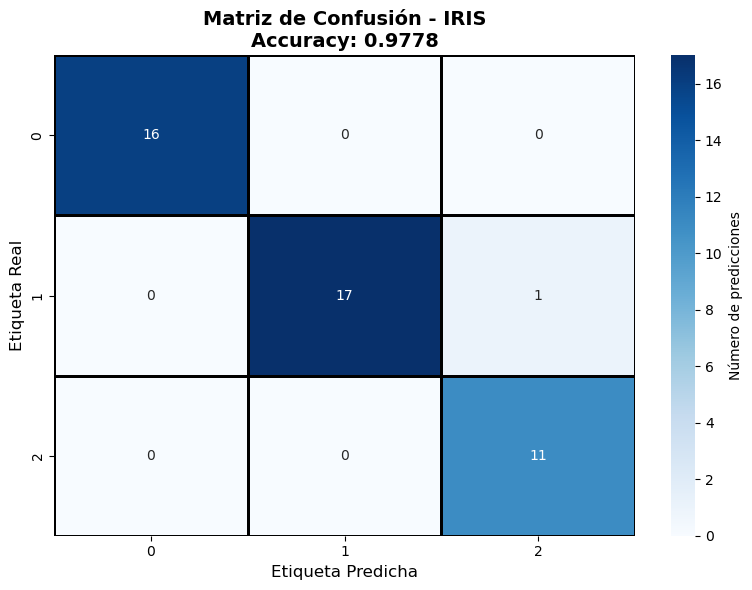

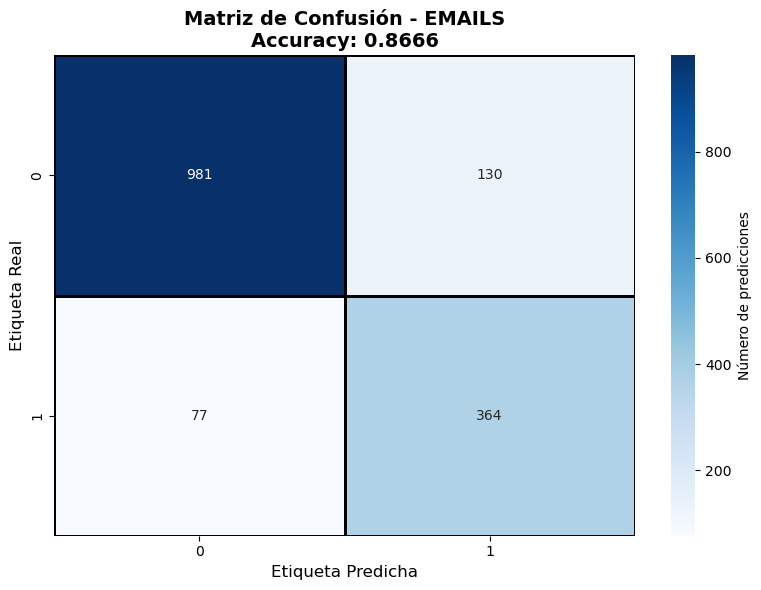

In [63]:
def plot_confusion_matrix(cm, dataset_name, accuracy):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                cbar_kws={'label': 'Número de predicciones'},
                linewidths=1, linecolor='black')
    plt.title(f'Matriz de Confusión - {dataset_name}\nAccuracy: {accuracy:.4f}', 
              fontsize=14, fontweight='bold')
    plt.ylabel('Etiqueta Real', fontsize=12)
    plt.xlabel('Etiqueta Predicha', fontsize=12)
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(cm_iris, "IRIS", accuracy_iris)
plot_confusion_matrix(cm_emails, "EMAILS", accuracy_emails)